# Modelo Predictivo — Predicción de Resultados de Fútbol

Entrenamos un clasificador para predecir el resultado de un partido:
`home_win`, `draw` o `away_win`.

**Enfoque honesto:** el fútbol es impredecible por naturaleza.
El objetivo no es acertar siempre sino demostrar el proceso correcto:
baseline → modelo → evaluación con métricas apropiadas.

**Por qué no usamos accuracy:** el dataset tiene 49% home_win,
28% away_win y 23% draw. Un modelo que prediga siempre home_win
tendría 49% de accuracy sin aprender nada. Usaremos F1-score
macro, que penaliza ignorar las clases minoritarias.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Cargamos el dataset de features
df = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ {len(df):,} partidos cargados")
print(f"\nDistribución de clases:")
print(df['result'].value_counts())
print(f"\nEn porcentaje:")
print(df['result'].value_counts(normalize=True).round(3) * 100)

✅ 49,475 partidos cargados

Distribución de clases:
result
home_win    24244
away_win    13978
draw        11253
Name: count, dtype: int64

En porcentaje:
result
home_win    49.0
away_win    28.3
draw        22.7
Name: proportion, dtype: float64


## 1. División temporal del dataset

Usamos división cronológica, no aleatoria. Con datos temporales,
una división aleatoria permitiría entrenar con partidos de 2020
y evaluar con partidos de 2010 — el modelo vería el futuro.

El corte al 80% garantiza que el modelo nunca ve durante el
entrenamiento ningún partido posterior a la fecha de corte.

In [2]:
# División temporal — no aleatoria
# Usamos los primeros 80% de partidos como train y el último 20% como test
corte = int(len(df) * 0.80)
fecha_corte = df.iloc[corte]['date']

train = df.iloc[:corte]
test  = df.iloc[corte:]

print(f"Fecha de corte:  {fecha_corte.date()}")
print(f"Train: {len(train):,} partidos ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test:  {len(test):,}  partidos ({test['date'].min().date()} → {test['date'].max().date()})")
print()
print("Distribución en train:")
print(train['result'].value_counts(normalize=True).round(3) * 100)
print()
print("Distribución en test:")
print(test['result'].value_counts(normalize=True).round(3) * 100)

Fecha de corte:  2016-03-28
Train: 39,580 partidos (1872-11-30 → 2016-03-28)
Test:  9,895  partidos (2016-03-28 → 2026-06-27)

Distribución en train:
result
home_win    49.3
away_win    28.1
draw        22.6
Name: proportion, dtype: float64

Distribución en test:
result
home_win    47.6
away_win    29.0
draw        23.3
Name: proportion, dtype: float64


## 2. Baseline — el modelo tonto

Antes de entrenar cualquier modelo real, establecemos el piso mínimo:
un clasificador que siempre predice la clase más frecuente (`home_win`).
Cualquier modelo que no supere estas métricas no aprendió nada útil.

In [3]:
# Definimos features y target
features = [
    'is_neutral', 'is_friendly',
    'home_form_5', 'home_goals_scored_avg5', 'home_goals_conceded_avg5',
    'away_form_5', 'away_goals_scored_avg5', 'away_goals_conceded_avg5',
    'h2h_total', 'h2h_home_winrate'
]

X_train = train[features]
y_train = train['result']
X_test  = test[features]
y_test  = test['result']

# Baseline: siempre predice la clase más frecuente (home_win)
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== BASELINE (siempre predice home_win) ===")
print(classification_report(y_test, y_pred_baseline,
                            target_names=['away_win', 'draw', 'home_win']))

=== BASELINE (siempre predice home_win) ===
              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00      2874
        draw       0.00      0.00      0.00      2307
    home_win       0.48      1.00      0.65      4714

    accuracy                           0.48      9895
   macro avg       0.16      0.33      0.22      9895
weighted avg       0.23      0.48      0.31      9895



/Users/angelasap107/Trabajo/Portafolio/football-analytics/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/angelasap107/Trabajo/Portafolio/football-analytics/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/angelasap107/Trabajo/Portafolio/football-analytics/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param

## 3. Random Forest

Entrenamos 200 árboles de decisión. Cada árbol vota por un resultado
y gana la mayoría. Usamos `class_weight='balanced'` para que el modelo
no ignore los empates por ser la clase menos frecuente.

In [4]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,      # 200 árboles
    max_depth=8,           # profundidad máxima por árbol
    min_samples_leaf=20,   # mínimo 20 partidos por hoja
    class_weight='balanced', # compensa el desbalance de clases
    random_state=42,
    n_jobs=-1              # usa todos los núcleos del Mac
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf,
                            target_names=['away_win', 'draw', 'home_win'],
                            zero_division=0))

# Comparación directa
f1_baseline = f1_score(y_test, y_pred_baseline, 
                        average='macro', zero_division=0)
f1_rf       = f1_score(y_test, y_pred_rf, 
                        average='macro', zero_division=0)

print(f"Macro F1 — Baseline:      {f1_baseline:.3f}")
print(f"Macro F1 — Random Forest: {f1_rf:.3f}")
print(f"Mejora:                   +{f1_rf - f1_baseline:.3f}")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    away_win       0.51      0.55      0.53      2874
        draw       0.29      0.38      0.33      2307
    home_win       0.69      0.55      0.61      4714

    accuracy                           0.51      9895
   macro avg       0.50      0.49      0.49      9895
weighted avg       0.54      0.51      0.52      9895

Macro F1 — Baseline:      0.215
Macro F1 — Random Forest: 0.490
Mejora:                   +0.275


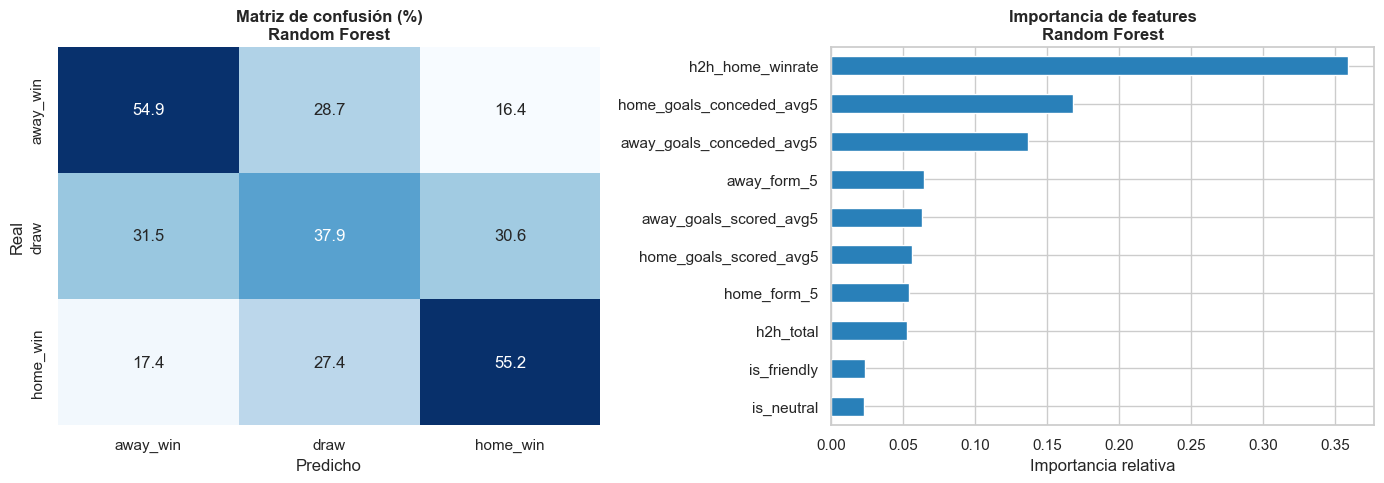

✅ Guardada en reports/figures/


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Matriz de confusión ---
clases = ['away_win', 'draw', 'home_win']
cm = confusion_matrix(y_test, y_pred_rf, labels=clases)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=clases, yticklabels=clases,
    ax=axes[0], cbar=False
)
axes[0].set_title('Matriz de confusión (%)\nRandom Forest', 
                  fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# --- Importancia de features ---
importancias = pd.Series(rf.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

importancias.plot(kind='barh', ax=axes[1], 
                  color='#2980b9', edgecolor='white')
axes[1].set_title('Importancia de features\nRandom Forest',
                  fontweight='bold')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig('../reports/figures/05_modelo_evaluacion.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Guardada en reports/figures/")

### Resultados del modelo

**Macro F1: 0.490** vs baseline 0.215 — mejora de +0.275

El modelo aprende patrones reales más allá de "siempre predice local".
Los empates siguen siendo la clase más difícil (F1=0.33), 
consistente con la naturaleza impredecible del fútbol.

**Hallazgo de importancia de features:**
`h2h_home_winrate` es la feature más importante por amplio margen —
el historial directo entre dos equipos predice mejor el resultado
que la forma reciente de cada uno por separado.

`is_neutral` e `is_friendly` tienen baja importancia relativa,
pero no se descartan — pueden ser relevantes en contextos específicos.

**Limitación honesta:** con 10 features simples y fútbol internacional
de 150 años, 51% de accuracy y F1 macro de 0.49 es un resultado
respetable. Las casas de apuestas profesionales con modelos mucho
más complejos apenas superan el 55-60%.